# Source Catalog Loading, Plotting and Exploring Examples

In [1]:
import numpy as np
import os.path as op
import time

from astropy.io import ascii, fits
from astropy.table import Table, unique, join, vstack, Column, hstack
import astropy.units as u
from astropy.coordinates import SkyCoord

from astropy.cosmology import Planck18 as cosmo


from hetdex_tools.source_catalog import plot_source_group
from hetdex_api.elixer_widget_cls import ElixerWidget
from hetdex_api.query_widget import QueryWidget
from hetdex_api.amp_widget import AmpWidget
from hetdex_api.config import HDRconfig
from hetdex_api.detections import Detections

import matplotlib.pyplot as plt

import plotly.express as px

from tqdm import tqdm

In [2]:
%matplotlib inline

In [3]:
wavelya = 1215.67
waveoii = 3727.8
waveciv = 1549.5
waveheii = 1640.4

BADVAL = -999.0


In [4]:


def get_stats(col, badval=BADVAL):
    vals = col.filled(np.nan) if hasattr(col, 'filled') else col
    vals = np.array(vals, dtype=float)

    good = np.isfinite(vals) & (vals != badval)
    vals = vals[good]

    print(f"N       : {len(vals)}")
    print(f"min     : {np.nanmin(vals):.3e}")
    print(f"max     : {np.nanmax(vals):.3e}")
    print(f"median  : {np.nanmedian(vals):.3e}")
    print(f"mean    : {np.nanmean(vals):.3e}")
    print(f"std     : {np.nanstd(vals):.3e}")

In [5]:
config = HDRconfig('hdr5')

In [6]:
cat_version=1.4

In [7]:
# Enter the catalog version
source_table = Table.read('../hdr5/catalogs/source_catalog_5.0.2.z.fits')

In [8]:
source_name = source_table['source_name']
source_name2 = [src.replace('_',' ') for src in source_name]

In [9]:
source_table['source_name'] = source_name2

In [10]:
wave_rect = 2.0 * np.arange(1036) + 3470.0

In [20]:
sel_lose1 = (source_table['selected_det'] == False) & (source_table['line_id'] == 'n/a') & (source_table['det_type'] == 'line') & (source_table['linewidth'] > 6)

sel_lose2 = (source_table['source_type']!= 'n/a') & np.invert( (source_table['det_type']=='cont') * (source_table['gmag']>22)) #* sel_ccn

sel_lose = np.invert(sel_lose1) & sel_lose2

sel_best  = (source_table['flag_best']==1) & sel_lose

In [21]:
np.sum(sel_best)

3296101

In [22]:
selected_table = source_table[sel_best]

In [23]:
uniq_table_sel = unique(selected_table, keys=['source_id'])

star_sel = uniq_table_sel['source_id'][uniq_table_sel['source_type'] == 'star']
oii_sel = uniq_table_sel['source_id'][uniq_table_sel['source_type'] == 'oii']
lae_sel = uniq_table_sel['source_id'][uniq_table_sel['source_type'] == 'lae']
agn_sel = uniq_table_sel['source_id'][uniq_table_sel['source_type'] == 'agn']
lzg_sel = uniq_table_sel['source_id'][uniq_table_sel['source_type'] == 'lzg']

print('There are {} stars, {} OII emitters, {} AGN, {} lzgs and {} LAEs'. \
      format(np.size(star_sel), np.size(oii_sel), np.size(agn_sel), np.size(lzg_sel), np.size(lae_sel)))

There are 162692 stars, 577128 OII emitters, 19053 AGN, 20477 lzgs and 1639087 LAEs


In [24]:
selected_table['SemiMajorAxis'] = 3600*selected_table['a'].astype(np.float32)
selected_table['SemiMinorAxis'] = 3600*selected_table['b'].astype(np.float32)
selected_table['PositionAngle'] = selected_table['pa'].astype(np.float32)
selected_table.rename_column('ra_mean','RA')
selected_table.rename_column('dec_mean','DEC')
selected_table['z_hetdex'] = selected_table['z_hetdex'].astype(np.float32)
selected_table['z_hetdex_conf'] = selected_table['z_hetdex_conf'].astype(np.float32)
selected_table.rename_column('ra','RA_det')
selected_table.rename_column('dec','DEC_det')
selected_table.rename_column('linewidth', 'sigma')
selected_table.rename_column('linewidth_err','sigma_err')

selected_table.rename_column('flux_err_obs', 'flux_obs_err')
selected_table.rename_column('continuum_err_obs','continuum_obs_err')
selected_table.rename_column('CNN_Score_2D_Spectra', 'p_cnn')
#selected_table.rename_column('plae_classification', 'plya_classification')
#selected_table.remove_column('line_id')
#selected_table.rename_column('new_line_id','line_id')

In [25]:
get_stats( selected_table['lum_oii'][selected_table['lum_oii'] > 0])

N       : 558793
min     : 1.470e+27
max     : 5.130e+44
median  : 5.336e+40
mean    : 9.530e+40
std     : 1.381e+42


In [26]:
fluxden_u = 1e-17 * u.erg * u.s ** (-1) * u.cm ** (-2) * u.AA ** (-1)
flux_u = 1e-17 * u.erg * u.s ** (-1) * u.cm ** (-2)
lum_u = u.erg * u.s ** (-1)

In [27]:
selected_table['RA'].unit = u.deg
selected_table['DEC'].unit = u.deg
selected_table['RA_det'].unit = u.deg
selected_table['DEC_det'].unit = u.deg
selected_table['wave'].unit = u.AA
selected_table['wave_err'].unit = u.AA
selected_table['flux'].unit = flux_u
selected_table['flux_err'].unit = flux_u
selected_table['sigma'].unit = u.AA
selected_table['sigma_err'].unit = u.AA
selected_table['continuum'].unit = fluxden_u
selected_table['continuum_err'].unit = fluxden_u
selected_table['flux_obs'].unit = flux_u
selected_table['flux_obs_err'].unit = flux_u
selected_table['continuum_obs'].unit = fluxden_u
selected_table['continuum_obs_err'].unit = fluxden_u
selected_table['flux_noise_1sigma'].unit = flux_u
selected_table['flux_noise_1sigma_obs'].unit = flux_u
selected_table['flux_aper'].unit = flux_u
selected_table['flux_aper_err'].unit = flux_u
selected_table['flux_aper_obs'].unit = flux_u
selected_table['flux_aper_obs_err'].unit = flux_u
selected_table['major'].unit = u.arcsec
selected_table['minor'].unit = u.arcsec
selected_table['src_separation'].unit = u.degree
selected_table['lum_oii'].unit = lum_u
selected_table['lum_oii_err'].unit = lum_u
selected_table['lum_lya'].unit = lum_u
selected_table['lum_lya_err'].unit = lum_u
selected_table['flux_oii'].unit = flux_u
selected_table['flux_oii_err'].unit = flux_u
selected_table['flux_lya'].unit = flux_u
selected_table['flux_lya_err'].unit = flux_u
selected_table['wave_group_a'].unit= u.degree
selected_table['wave_group_b'].unit= u.degree


In [28]:
column_description = {
    'source_id': 'HETDEX Source Identifier',
    'source_name': 'HETDEX IAU designation',
    'source_type': "options are 'star', 'lae', 'agn', 'lzg', 'oii', 'none'",
    'RA': 'source_id right ascension (ICRS deg)',
    'DEC': 'source_id declination (ICRS deg)',
    'detectid': 'emission line or detection ID',
    'selected_det': 'best detectid for Lya flux or OII line flux',
    'RA_det': 'detectid right ascension (ICRS deg)',
    'DEC_det': 'detectid declination (ICRS deg)',
    'det_type': "detection type: 'line' or 'continuum'",
    'src_separation': 'distance between detectid (RA_det, DEC_det) and the source center (RA, DEC)',
    'wave': 'central wavelength of line emission',
    'wave_err': 'mcmc error in wave',
    'gmag': 'sdss-g magnitude measured in HETDEX spectrum',
    #'gmag_err': 'mcmc uncertainty in gmag',
    'flux_obs': 'observed line flux',
    'flux_obs_err': 'mcmc error in observed line flux',
    'flux': 'dust corrected line flux at "wave"',
    'flux_err': 'mcmc error in dust corrected line flux',
    'flux_aper': 'Dust corrected, OII line flux measured in elliptical galaxy aperture ',
    'flux_aper_err': 'error in flux_aper',
    'flux_aper_obs': 'OII line flux measured in elliptical aperture',
    'flux_aper_obs_err': 'error in flag_aper_obs',
    'flag_aper': '1 = OII aperture line flux used, -1= PSF-line flux used from "flux" column',
    'flux_noise_1sigma': 'dust corrected 1 sigma flux sensitivity',
    'flux_noise_1sigma_obs': 'observed 1 sigma flux sensitivity',
    'sn': 'signal-to-noise for line emission',
    'sn_err': 'mcmc error in signal-to-noise',
    'sigma': 'sigma linewidth in gaussian line fit (\AA)',
    'sigma_err': 'mcmc error in sigma linewidth (\AA)',
    'z_hetdex': 'HETDEX spectroscopic redshift',
    'z_hetdex_src': 'HETDEX spectroscopic redshift source',
    'z_hetdex_conf': '0 to 1 confidence HETDEX spectroscopic redshift source',
    'line_id':'line identification at observed wavelength (wave) assuming redshift of z_hetdex',
    'plya_classification': r'0 to 1 on likelihood line is Lya', 
    'continuum': 'local fitted observed continuum',
    'continuum_err': 'mcmc error in continuum',
    'continuum_obs': 'local fitted observed continuum',
    'continuum_obs_err': 'mcmc error in continuum',
    'Av': 'applied dust correction in V band',
    'ebv': 'applied selective extinction',
    'apcor': 'aperture correction applied to spectrum at 4500\AA',
    'chi2': 'reduced $\chi^2$ quality of line fit',
    'chi2_err': 'mcmc uncertainty in reduced $\chi^2$',  
    'counterpart_mag': 'selected closest counterpart mag from imaging data',
    'counterpart_mag_err': 'uncertainty in counterpart_mag',
    'counterpart_dist': 'distance to closest counterpart',
    'counterpart_catalog_name': 'image catalog source of counterpart',
    'counterpart_filter_name': 'image filter of countpart',
    'best_z': 'ELiXeR best redshift',
    'best_pz': 'confidence in best_z',
    'z_diagnose': 'Best fit redshift from Diagnose',
    'cls_diagnose':'Diagnose classfication."STAR", "GALAXY", "QSO", "UNKNOWN"',
    'stellartype': 'diagnose spectral type classification for stars',
    'agn_flag': '-1 not an AGN, 0 broad lien soruce, 1 confident AGN',
    'n_members': 'number of detections in the source group',
    'SemiMajorAxis': 'semi-major axis from spatial clustering in arcsec',
    'SemiMinorAxis': 'semi-minor axis from spatial clustering in arcsec',
    'PositionAngle': 'position angle of spatial clustering',
    'wave_group_id': 'id for 3D clustering at common ra, dec, wave',
    'wave_group_a':'semi-major axis from 3D FOF clustering',
    'wave_group_b':'semi-minor axis from 3D FOF clustering',
    'wave_group_pa':'positional angle from 3D FOF clustering',
    'wave_group_ra':'mean ra from 3D FOF clustering',
    'wave_group_dec':'mean dec from 3D FOF clustering',
    'wave_group_wave':'mean wavelength from 3D FOF clustering',
    'fwhm': 'measured seeing of the observation in arcsec',
    'throughput': 'relative spectral response at 4540 assuming a 360 s nominal exposure',
    'shotid': 'integer represent observation ID: int( date+obsid)',
    'field': 'field ID: cosmos, goods-n, dex-fall, dex-spring',
    'date': 'date',
    'obsid':'observation number',
    'multiframe': 'string identifier for the ifuslot/specid/ifuid/amp combination',
    'fiber_id':'string identifier for the highest weight fiber',
    'weight': 'flux weight of the highest weight fiber',
    'x_raw':'x value on the CCD of the detection (ds9 x value)',
    'y_raw':'y value on the CCD of the detection (ds9 y value)',
    'x_ifu':'x position in the ifu in arcsec',
    'y_ifu':'y position in the ifu in arcsec',
    'ra_aper': 'Right Ascension of aperture center of imaging counterpart in degrees',
    'dec_aper': 'Declination of aperture center of imaging counterpart in degrees',
    'catalog_name_aper' : 'Imaging source for measuring OII resolved apertures',
    'filter_name_aper': 'Filter of Imaging used for measuring OII resolved apertures',
    'dist_aper': 'distance between aperture center and detectid position in arcsec',
    'mag_aper': 'photometric magnitude in aperture in imaging source',
    'mag_aper_err': 'photometric magnitude error in aperture in imaging source',
    'major': 'Major axis of aperture ellipse of resolved OII galaxy defined by imaging',
    'minor': 'Minor axis of aperture ellipse of resolved OII galaxy defined by imaging',
    'theta': 'angle in aperture ellipse',
    'lum_lya': 'Lya luminosity in ergs/s', 
    'lum_lya_err': 'error in lum_lya',
    'lum_oii': 'best OII line luminosity',
    'lum_oii_err': 'error in lum_oii',
    'flux_lya': "dust corrected Lya line flux) in ergs/s", 
    'flux_lya_err': 'error in flux_lya',
    'flux_oii': 'best OII line flux',
    'flux_oii_err': 'error in flux_oii',
    'p_conf': 'LAE/Faint OII emitter confidence score from RF Classifier. 1=high confidence, 0=low confidence',
    'p_cnn': 'LAE/Faint OII emitter confidence score based on CNN Classifier. 1=high confidence, 0=low confidence',
}

In [29]:
column_description.keys()

dict_keys(['source_id', 'source_name', 'source_type', 'RA', 'DEC', 'detectid', 'selected_det', 'RA_det', 'DEC_det', 'det_type', 'src_separation', 'wave', 'wave_err', 'gmag', 'flux_obs', 'flux_obs_err', 'flux', 'flux_err', 'flux_aper', 'flux_aper_err', 'flux_aper_obs', 'flux_aper_obs_err', 'flag_aper', 'flux_noise_1sigma', 'flux_noise_1sigma_obs', 'sn', 'sn_err', 'sigma', 'sigma_err', 'z_hetdex', 'z_hetdex_src', 'z_hetdex_conf', 'line_id', 'plya_classification', 'continuum', 'continuum_err', 'continuum_obs', 'continuum_obs_err', 'Av', 'ebv', 'apcor', 'chi2', 'chi2_err', 'counterpart_mag', 'counterpart_mag_err', 'counterpart_dist', 'counterpart_catalog_name', 'counterpart_filter_name', 'best_z', 'best_pz', 'z_diagnose', 'cls_diagnose', 'stellartype', 'agn_flag', 'n_members', 'SemiMajorAxis', 'SemiMinorAxis', 'PositionAngle', 'wave_group_id', 'wave_group_a', 'wave_group_b', 'wave_group_pa', 'wave_group_ra', 'wave_group_dec', 'wave_group_wave', 'fwhm', 'throughput', 'shotid', 'field', 'dat

In [31]:
for col in selected_table.colnames:
    if col in column_description.keys():
        selected_table[col].description = column_description[col] 

# i think I can remove this
for col in selected_table.colnames:
    if col == 'selected_det':
        continue
    if isinstance(selected_table[col][0], str):
        selected_table[col] = selected_table[col].astype(str)
        print(col, ' is string')
    try:
        selected_table[col] = selected_table[col].filled(BADVAL)
        #print(col)
    except:
        pass
    
    if col in ['sn','flux','flux_err','flux_aper','flux_aper_err','flux_lya','flux_lya_err','lum_lya','lum_lya_err','flux_oii','flux_oii_err','lum_oii','lum_oii_err']:
        try:
            sel_zero = selected_table[col] == 0.0
            selected_table[col][sel_zero] = BADVAL
            print('zero fill', col, np.sum(sel_zero))
        except:
            pass

for col in selected_table.colnames:
    if col in ['lum_oii','lum_oii_err','lum_lya','lum_lya_err']:
        continue
    if selected_table[col].dtype == '>f8':
        print(col)
        selected_table[col] = selected_table[col].astype(np.float32)

In [32]:
selected_det = (selected_table['selected_det'] == True) & (selected_table['p_conf']>=0.5) * (selected_table['p_cnn']>=0.5)

uniq_obs_table = unique(selected_table[selected_det], keys=['source_id','shotid'])

star_sel = uniq_obs_table['source_id'][uniq_obs_table['source_type'] == 'star']
oii_sel = uniq_obs_table['source_id'][uniq_obs_table['source_type'] == 'oii']
lae_sel = uniq_obs_table['source_id'][uniq_obs_table['source_type'] == 'lae']
agn_sel = uniq_obs_table['source_id'][uniq_obs_table['source_type'] == 'agn']
lzg_sel = uniq_obs_table['source_id'][uniq_obs_table['source_type'] == 'lzg']

print('There are {} stars, {} OII emitters, {} AGN, {} lzgs and {} LAEs'. \
      format(np.size(star_sel), np.size(oii_sel), np.size(agn_sel), np.size(lzg_sel), np.size(lae_sel)))

There are 150608 stars, 491411 OII emitters, 18303 AGN, 19457 lzgs and 426654 LAEs


In [33]:
obs_table_dict = {
    'source_name': 'S26',
    'source_id': '<i8',
    'shotid': '<i8',
    'RA': 'f8', 
    'DEC': 'f8',
    'RA_det': 'f8', 
    'DEC_det': 'f8',
    'gmag': 'f4',
    'Av' : 'f4',
#    'SemiMajorAxis': 'f4',
#    'SemiMinorAxis': 'f4',
#    'PositionAngle': 'f4',
    'z_hetdex': 'f4',
    'z_hetdex_src': 'S8',
    'z_hetdex_conf': 'f4',
    'source_type': 'S4',
    'n_members':'i4',
    'detectid': 'i8',
    'field': 'S10',
    'flux': 'f4',
    'flux_err': 'f4',
    'flux_aper': 'f4',
    'flux_aper_err': 'f4',
    'flag_aper': '<i4',
    'major':'f4',
    'minor':'f4',
    'theta': 'f4',
    'lum_lya':'f8',
    'lum_lya_err':'f48',
    'lum_oii':'f8',
    'lum_oii_err':'f8',
    'flux_lya': 'f4',
    'flux_lya_err': 'f4',
    'flux_oii': 'f4',
    'flux_oii_err': 'f4',
    'sn':'f4',
    'apcor':'f4',
    'p_conf':'f4',
    'p_cnn':'f4',
    }

obs_table = uniq_obs_table[list(obs_table_dict.keys())]

In [34]:
len(obs_table)

1107763

In [36]:
import tables as tb

In [37]:
elixh5 = tb.open_file(config.elixerh5, 'r')

In [39]:
elixh5 = tb.open_file(config.elixerh5, 'r')
spectra_table = Table( elixh5.root.CalibratedSpectra.read())

#wd_corr = Table.read('../hetdex_api/known_issues/hdr3/wdcor.txt', format='ascii.no_header')
#spectra_table['spec'] /= wd_corr['col2']
#spectra_table['spec_err'] /= wd_corr['col2']
#spectra_table['spec_obs'] /= wd_corr['col2']
#spectra_table['spec_err_obs'] /= wd_corr['col2']

In [40]:
spectra_table['spec'] = spectra_table['flux']/2.0
spectra_table['spec_err'] = spectra_table['flux_err']/2.0

In [41]:

def make_spec_catalog(tab, outname='test.fits'):
    # Join (do NOT sort yet)
    obs_spec_table = join(tab, spectra_table['detectid', 'spec', 'spec_err'], join_type='left')

    # --- compute sort index from a small 1-D column ---
    #order = np.argsort(obs_spec_table['z_hetdex'])
    order = np.argsort(obs_spec_table['z_hetdex'])[::-1]

    # --- INFO table: select only INFO cols first, then apply index ---
    info_cols = list(obs_table_dict.keys())
    info_tbl = obs_spec_table[info_cols][order]          # touches only small columns
    # Ensure masks are filled so BinTableHDU sees plain Columns
    info_tbl = info_tbl.filled(np.nan)

    # --- spectra: pull as plain ndarrays, strip masks, then reorder with 'order' ---
    spec_arr     = np.ma.getdata(obs_spec_table['spec']).astype(np.float32, copy=False)
    spec_err_arr = np.ma.getdata(obs_spec_table['spec_err']).astype(np.float32, copy=False)

    # spec_arr has shape (nrow, nlambda); reorder rows by 'order' then transpose to (nlambda, nspec)
    spec_img     = np.ascontiguousarray(spec_arr[order].T)
    spec_err_img = np.ascontiguousarray(spec_err_arr[order].T)

    # --- wavelength vector/image ---
    wave_img = np.ascontiguousarray(np.ma.getdata(wave_rect).astype(np.float32, copy=False))

    # --- assemble HDUs ---
    hdus = [
        fits.PrimaryHDU(),
        fits.BinTableHDU(info_tbl, name='INFO'),
        fits.ImageHDU(spec_img,     name='SPEC'),
        fits.ImageHDU(spec_err_img, name='SPEC_ERR'),
        fits.ImageHDU(wave_img,     name='WAVELENGTH'),
    ]
    hdu = fits.HDUList(hdus)

    # headers
    unit = '1e-17 erg s-1 cm-2 Angstrom-1'
    hdu['SPEC'].header['BUNIT']     = unit
    hdu['SPEC_ERR'].header['BUNIT'] = unit
    hdu['WAVELENGTH'].header['BUNIT'] = 'Angstrom'
    hdu['SPEC'].header['COMMENT']   = 'Dust-corrected, 1D PSF-extracted, aperture-corrected spectra'

    hdu.writeto(outname, overwrite=True)
    return info_tbl

In [42]:
obs_table_output = make_spec_catalog(obs_table, outname=f'hetdex_source_catalog_2/hetdex_sc2_spec_v{cat_version}.fits')

In [43]:
#obs_table_output.write(f'hetdex_source_catalog_2/hetdex_sc2_v{cat_version}.ecsv')
obs_table_output.write(f'hetdex_source_catalog_2/hetdex_sc2_v{cat_version}.dat', format='ascii', overwrite=True)

In [44]:
obs_table_output.write(f'hetdex_source_catalog_2/hetdex_sc2_v{cat_version}.fits', overwrite=True)

In [45]:
mylatexdict = ascii.latex.latexdicts['AA']
mylatexdict['tabletype'] = 'table*'
mylatexdict['preamble'] = r'\begin{center}'
mylatexdict['tablefoot'] = r'\end{center}'

mylatexdict['caption'] = r'HETDEX Source Observation Example\label{tab:det_cat}'
obs_table_output[0:20].write('HETDEX_src_catalog.tex', format='latex', overwrite=True,
                           latexdict=mylatexdict, formats={'z$\_$spec':'%4.3f'})

# Make the line flux table

In [46]:
line_table_cols = [
    'source_id',
    'source_name',
    'RA',
    'DEC',
    'z_hetdex',
    'z_hetdex_src',
    'z_hetdex_conf',
    'source_type',
    'detectid',
    'selected_det',
    'det_type',
    'line_id',
    'p_conf',
    'p_cnn',
    'RA_det',
    'DEC_det',
    'src_separation',
    'n_members',
    #'gmag_err',
    'gmag',
    'Av',
    'ebv',
    'wave',
    'wave_err',
    'flux',
    'flux_err',
    'flux_obs',
    'flux_obs_err',
    'flux_aper',
    'flux_aper_err',
    'flux_aper_obs',
    'flux_aper_obs_err',
    'flag_aper',
    'sigma',
    'sigma_err',
    'continuum',
    'continuum_err',
    'continuum_obs',
    'continuum_obs_err',
    'sn',
    'sn_err',
    'chi2',
    'chi2_err',
    'flux_noise_1sigma_obs',
    'flux_noise_1sigma',
    'apcor',
    'counterpart_mag',
    'counterpart_mag_err',
    'counterpart_dist',
    'counterpart_catalog_name',
    'counterpart_filter_name',
    'plya_classification',
    'z_elixer',
    'best_pz',
    #'best_z',
    #'best_pz',
    'z_diagnose',
    'cls_diagnose',
    'stellartype',
    'agn_flag',
    #'SemiMajorAxis',
    #'SemiMinorAxis',
    #'PositionAngle',
    'wave_group_id',
    'wave_group_a',
    'wave_group_b',
    'wave_group_pa',
    'wave_group_ra',
    'wave_group_dec',
    'wave_group_wave',
    'fwhm',
    'throughput',
    'shotid',
    'field',
    'date',
    'obsid',
    'multiframe',
    'fiber_id',
    'weight',
    'x_raw',
    'y_raw',
    'x_ifu',
    'y_ifu',
    'ra_aper',
    'dec_aper',
    'catalog_name_aper',
    'filter_name_aper',
    'dist_aper',
    'mag_aper',
    'mag_aper_err',
    'major',
    'minor',
    'theta',
]

In [47]:
selected_table['wave_group_id'][selected_table['wave_group_id'] == 0] = -1

In [48]:
mylatexdict = ascii.latex.latexdicts['AA']
mylatexdict['tabletype'] = 'table*'
mylatexdict['preamble'] = r'\begin{center}'
mylatexdict['tablefoot'] = r'\end{center}'

In [49]:
column_description = {
    'source_id': 'HETDEX Source Identifier',
    'source_name': 'HETDEX IAU designation',
    'source_type': "options are 'star', 'lae', 'agn', 'lzg', 'oii', 'none'",
    'RA': 'source_id right ascension (ICRS deg)',
    'DEC': 'source_id declination (ICRS deg)',
    'detectid': 'emission line or detection ID',
    'selected_det': 'best detectid for Ly$\alpha$ flux or OII line flux',
    'RA_det': 'detectid right ascension (ICRS deg)',
    'DEC_det': 'detectid declination (ICRS deg)',
    'det_type': "detection type: 'line' or 'continuum'",
    'src_separation': 'the separation in arcsec between the detectid (RA_det, DEC_det) and the source_id center (RA, DEC)',
    'wave': 'central wavelength of line emission (\AA)',
    'wave_err': 'mcmc error in wave (\AA)',
    'gmag': 'sdss-g magnitude measured in HETDEX spectrum',
    'gmag_err': 'mcmc uncertainty in gmag',
    'flux_obs': 'observed line flux $10^{-17} \mathrm{erg/s/cm^2}$',
    'flux_obs_err': 'mcmc error in observed line flux',
    'flux': 'dust corrected line flux $10^{-17} \mathrm{erg/s/cm^2}$',
    'flux_err': 'mcmc error in dust corrected line flux',
    'flux_aper': 'Dust corrected, OII line flux measured in elliptical galaxy aperture in $10^{-17}\mathrm{erg/s/cm^2}$',
    'flux_aper_err': 'error in flux_aper',
    'flux_aper_obs': 'OII line flux measured in elliptical galaxy aperture in $10^{-17}\mathrm{erg/s/cm^2}$',
    'flux_aper_obs_err': 'error in flag_aper_obs',
    'flag_aper': '1 = aperture line flux used for lum_oii, -1= PSF-line flux used from "flux" column',
    'flux_noise_1sigma': 'dust corrected 1 sigma flux sensitivity in $10^{-17}\mathrm{erg/s/cm^2}$',
    'flux_noise_1sigma_obs': 'observed 1 sigma flux sensitivity in $10^{-17}\mathrm{erg/s/cm^2}$',
    'sn': 'signal-to-noise for line emission',
    'sn_err': 'mcmc error in signal-to-noise',
    'sigma': 'sigma linewidth in gaussian line fit (\AA)',
    'sigma_err': 'mcmc error in sigma linewidth (\AA)',
    'z_hetdex': 'HETDEX spectroscopic redshift',
    'z_hetdex_src': 'HETDEX spectroscopic redshift source',
    'z_hetdex_conf': '0 to 1 confidence HETDEX spectroscopic redshift source',
    'line_id':'line identification at observed wavelength (wave) assuming redshift of z_hetdex',
    'plya_classification': r'0 to 1 on likelihood line is Ly$\alpha$', 
    'continuum': 'local fitted observed continuum $10^{-17}$ \mathrm{erg/s/cm^2$/}\AA',
    'continuum_err': 'mcmc error in continuum',
    'continuum_obs': 'local fitted observed continuum $10^{-17}$ \mathrm{erg/s/cm^2$/}\AA',
    'continuum_obs_err': 'mcmc error in continuum',
    'Av': 'applied dust correction in V band',
    'ebv': 'applied selective extinction',
    'apcor': 'aperture correction applied to spectrum at 4500\AA',
    'chi2': 'reduced $\chi^2$ quality of line fit',
    'chi2_err': 'mcmc uncertainty in reduced $\chi^2$',  
    'counterpart_mag': 'selected closest counterpart mag from source extracting on image data',
    'counterpart_mag_err': 'uncertainty in counterpart_mag',
    'counterpart_dist': 'distance to closest counterpart',
    'counterpart_catalog_name': 'image catalog source of counterpart',
    'counterpart_filter_name': 'image filter of countpart',
    'best_z': 'ELiXeR best redshift',
    'best_pz': 'confidence in best_z',
    'z_diagnose': 'Best fit redshift from Diagnose',
    'cls_diagnose':'Best classification from Diagnose. Options are "STAR", "GALAXY", "QSO", "UNKNOWN"',
    'stellartype': 'diagnose spectral type classification for stars',
    'agn_flag': '-1 not an AGN, 0 broad line source but not confirmed AGN, 1 confident AGN and z_hetdex',
    'n_members': 'number of detections in the source group',
    'SemiMajorAxis': 'semi-major axis from spatial clustering in arcsec',
    'SemiMinorAxis': 'semi-minor axis from spatial clustering in arcsec',
    'PositionAngle': 'position angle of spatial clustering',
    'wave_group_id': 'id for 3D clustering at common ra, dec, wave',
    'wave_group_a':'semi-major axis from 3D FOF clustering',
    'wave_group_b':'semi-minor axis from 3D FOF clustering',
    'wave_group_pa':'positional angle from 3D FOF clustering',
    'wave_group_ra':'mean ra from 3D FOF clustering',
    'wave_group_dec':'mean dec from 3D FOF clustering',
    'wave_group_wave':'mean wavelength from 3D FOF clustering',
    'fwhm': 'measured seeing of the observation in arcsec',
    'throughput': 'relative spectral response at 4540 assuming a 360 s nominal exposure',
    'shotid': 'integer represent observation ID: int( date+obsid)',
    'field': 'field ID: cosmos, goods-n, dex-fall, dex-spring',
    'date': 'date',
    'obsid':'observation number',
    'multiframe': 'string identifier for the ifuslot/specid/ifuid/amp combination',
    'fiber_id':'string identifier for the highest weight fiber',
    'weight': 'flux weight of the highest weight fiber',
    'x_raw':'x value on the CCD of the detection (ds9 x value)',
    'y_raw':'y value on the CCD of the detection (ds9 y value)',
    'x_ifu':'x position in the ifu in arcsec',
    'y_ifu':'y position in the ifu in arcsec',
    'ra_aper': 'Right Ascension of aperture center of imaging counterpart in degrees',
    'dec_aper': 'Declination of aperture center of imaging counterpart in degrees',
    'catalog_name_aper' : 'Imaging source for measuring OII resolved apertures',
    'filter_name_aper': 'Filter of Imaging used for measuring OII resolved apertures',
    'dist_aper': 'distance between aperture center and detectid position in arcsec',
    'mag_aper': 'photometric magnitude in aperture in imaging source',
    'mag_aper_err': 'photometric magnitude error in aperture in imaging source',
    'major': 'Major axis of aperture ellipse of resolved OII galaxy defined by imaging',
    'minor': 'Minor axis of aperture ellipse of resolved OII galaxy defined by imaging',
    'theta': 'angle in aperture ellipse',
    'lum_lya': 'Ly$\alpha$ luminosity and error calculated from "flux" column (ie. dust corrected Lya line flux) in ergs/s', 
    'lum_lya_err': 'error in lum_lya',
    'lum_oii': 'OII line luminosity and error calculated from "flux" column if flag_aper=-1 or "flux_aper" column if flag_aper=1 in $10^{-17}$ ergs/s/cm$^2$',
    'lum_oii_err': 'error in lum_oii',
    'flux_lya': 'Ly$\alpha$ flux calculated from "flux" column for (ie. dust corrected Lya line flux) in ergs/s', 
    'flux_lya_err': 'error in flux_lya',
    'flux_oii': 'OII line flux calculated from "flux" column if flag_aper=0 or "flux_aper" column if flag_aper=1 in $10^{-17}$ ergs/s/cm$^2$',
    'flux_oii_err': 'error in flux_oii',
}

In [50]:
output_table = selected_table[line_table_cols]
output_table.sort('source_id')

In [51]:
detfilename = f'hetdex_source_catalog_2/hetdex_sc2_detinfo_v{cat_version}'
output_table.write(detfilename+'.dat', format='ascii', overwrite=True)

In [52]:
#output_table.write(detfilename + '.ecsv')

In [53]:
output_table.write(detfilename + '.fits', overwrite=True)

In [54]:
test = Table.read(detfilename + '.fits')

In [55]:
del selected_table, source_table

In [116]:
np.savetxt('fulllist.dets', output_table['detectid'], fmt="%i")

In [149]:
detectid_list =output_table['detectid']

In [150]:
# Get lists to copy over elixer reports
from collections import defaultdict
from pathlib import Path


In [151]:
# group_id definition: 30000..50002 etc
group_ids = detectid_list // 100000   # e.g. 3000630353 -> 30006
out_dir = Path( 'elixer_det_lists')

In [156]:
np.savetxt( 'group_id.list', np.unique( group_ids), fmt="%i")

In [153]:
groups = defaultdict(list)

# ---- accumulate detectids per group ----
for det, gid in zip(detectid_list, group_ids):
    # if you want to restrict to a range, uncomment:
    # if not (30000 <= gid <= 50002):
    #     continue
    groups[gid].append(det)

# ---- write one .dets file per group ----
for gid in sorted(groups.keys()):
    group_arr = np.array(groups[gid], dtype=np.int64)
    out_path = out_dir / f"{gid}.dets"
    np.savetxt(out_path, group_arr, fmt="%d")
    print(f"Wrote {out_path} with {len(group_arr)} detectids")

Wrote elixer_det_lists/30000.dets with 2062 detectids
Wrote elixer_det_lists/30001.dets with 4273 detectids
Wrote elixer_det_lists/30002.dets with 5165 detectids
Wrote elixer_det_lists/30003.dets with 8739 detectids
Wrote elixer_det_lists/30004.dets with 11874 detectids
Wrote elixer_det_lists/30005.dets with 8585 detectids
Wrote elixer_det_lists/30006.dets with 14423 detectids
Wrote elixer_det_lists/30007.dets with 10069 detectids
Wrote elixer_det_lists/30008.dets with 13883 detectids
Wrote elixer_det_lists/30009.dets with 10957 detectids
Wrote elixer_det_lists/30010.dets with 16906 detectids
Wrote elixer_det_lists/30011.dets with 14355 detectids
Wrote elixer_det_lists/30012.dets with 11922 detectids
Wrote elixer_det_lists/30013.dets with 12396 detectids
Wrote elixer_det_lists/30014.dets with 12510 detectids
Wrote elixer_det_lists/30015.dets with 9856 detectids
Wrote elixer_det_lists/30016.dets with 9713 detectids
Wrote elixer_det_lists/30017.dets with 10106 detectids
Wrote elixer_det_

30000
30000
30000
30000
30000
30000
30900
30000
30000
30000
30000


# Vacuum wavelength tests

In [79]:
detfilename = 'hetdex_source_catalog_1/hetdex_sc1_detinfo_v3.2'
test = Table.read(detfilename + '.ecsv')

In [85]:
sel_lae = ( test['source_type'] == 'lae') & (test['z_hetdex'] > 1.8) & (test['selected_det']==True) & (test['n_members']==1)

lae_sample = test['source_id','detectid','RA','DEC','source_type','wave','z_hetdex','best_z','shotid'][sel_lae]

In [107]:
import hetdex_api.wave as wv
from multiprocessing import Pool

In [119]:
#directly lifted from specutils with some modifications
def air_to_vac(wavelength):
    """
    Implements the air to vacuum wavelength conversion described in eqn 65 of
    Griesen 2006

    !!! warning ... does not check for 2000AA normal cutoff ....

    """

    try:

        if not hasattr(wavelength,"value"):
            wavelength = wavelength * u.angstrom
            strip_unit = True
        else:
            strip_unit = False

        wlum = wavelength.to(u.um).value
        val = (1+1e-6*(287.6155+1.62887/wlum**2+0.01360/wlum**4)) * wavelength

        if strip_unit:
            val = val.value
        return val
    except:
        log.warning("Exception in spectrum_utilities air_to_vac().",exc_info=True)
        return None


In [101]:
def get_wave_corr_mp(i):
    return wv.get_wave_corr(lae_sample['wave'][i], shotid=lae_sample['shotid'][i])

In [108]:
P = Pool()
res = P.map( get_wave_corr_mp, np.arange(0, len(lae_sample)))

In [110]:
wave_corr = []
for r in res:
    wave_corr.append(float(r))

In [121]:
lae_sample['wave_vac'] = wv.get_wave_corr(lae_sample['wave'])
lae_sample['wave_corr'] = wave_corr
lae_sample['wave_vac2'] = air_to_vac(lae_sample['wave'])

In [122]:
lae_sample['z_air'] = lae_sample['wave']/wavelya - 1
lae_sample['z_vac'] = lae_sample['wave_vac']/wavelya - 1
lae_sample['z_vac2'] = lae_sample['wave_vac2']/wavelya - 1

lae_sample['z_corr'] = lae_sample['wave_corr']/wavelya - 1

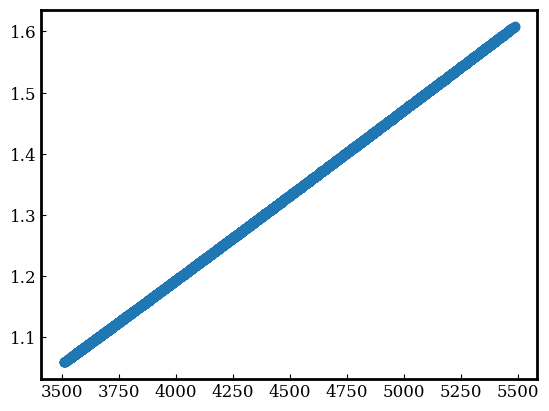

In [139]:
plt.scatter(lae_sample['wave'] , lae_sample['wave_vac2']-lae_sample['wave'])

In [134]:
plt.style.use('default')
plt.rcParams['axes.linewidth'] = 2
plt.rcParams.update({'font.size': 14})

plt.rcParams['lines.linewidth'] = 2

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'
plt.rcParams['xtick.labelsize']= 12.0
plt.rcParams['ytick.labelsize']= 12.0

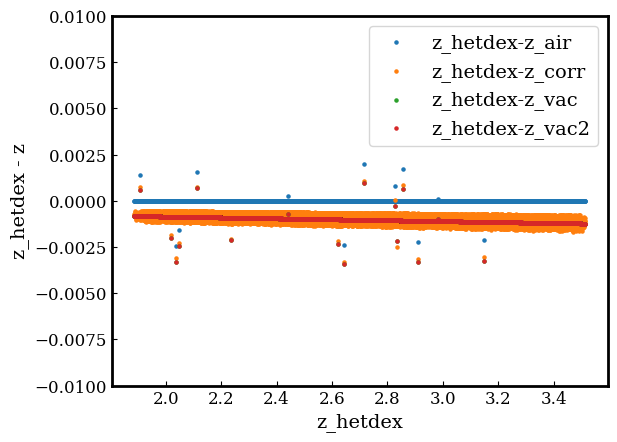

In [135]:
plt.scatter(lae_sample['z_hetdex'], lae_sample['z_hetdex']- lae_sample['z_air'], s=5, label='z_hetdex-z_air')
plt.scatter(lae_sample['z_hetdex'], lae_sample['z_hetdex']- lae_sample['z_corr'], s=5, label='z_hetdex-z_corr')
plt.scatter(lae_sample['z_hetdex'], lae_sample['z_hetdex']- lae_sample['z_vac'], s=5, label='z_hetdex-z_vac')
plt.scatter(lae_sample['z_hetdex'], lae_sample['z_hetdex']- lae_sample['z_vac'], s=5, label='z_hetdex-z_vac2')
plt.xlabel('z_hetdex')
plt.ylabel('z_hetdex - z')
plt.ylim(-0.01, 0.01)
plt.legend()

Text(0.5, 0, 'z_hetdex')

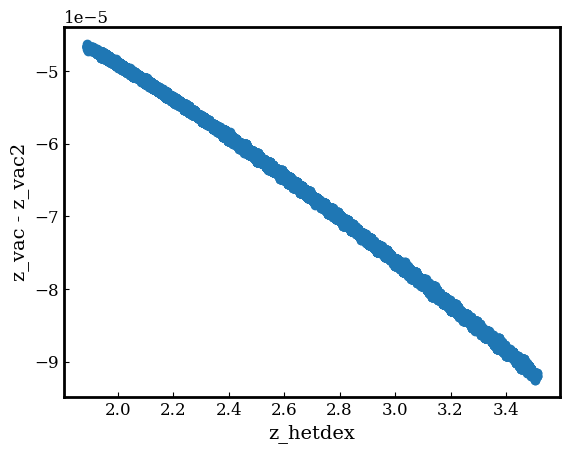

In [136]:
plt.scatter(lae_sample['z_hetdex'], lae_sample['z_vac']- lae_sample['z_vac2'])
plt.ylabel('z_vac - z_vac2')
plt.xlabel('z_hetdex')

In [84]:
lae_sample['z_air'] = lae_sample['wave']/wavelya - 1

In [40]:
EW = ElixerWidget(detectlist=lae_sample['detectid'][1000])

interactive(children=(Text(value='2101958662', description='DetectID:', placeholder='2101958662'), Output()), …

In [ ]:
np.unique(output_table['det_type'], return_counts=True)

In [29]:
test[test['source_id'] == test['source_id'][test['detectid'] == 2190066659] ]

source_id,source_name,RA,DEC,z_hetdex,z_hetdex_src,z_hetdex_conf,source_type,detectid,selected_det,det_type,line_id,RA_det,DEC_det,src_separation,n_members,gmag_err,gmag,Av,ebv,wave,wave_err,flux,flux_err,flux_obs,flux_obs_err,flux_aper,flux_aper_err,flux_aper_obs,flux_aper_obs_err,flag_aper,sigma,sigma_err,continuum,continuum_err,continuum_obs,continuum_obs_err,sn,sn_err,chi2,chi2_err,flux_noise_1sigma_obs,flux_noise_1sigma,apcor,counterpart_mag,counterpart_mag_err,counterpart_dist,counterpart_catalog_name,counterpart_filter_name,plya_classification,best_z,best_pz,z_diagnose,cls_diagnose,stellartype,agn_flag,wave_group_id,wave_group_a,wave_group_b,wave_group_pa,wave_group_ra,wave_group_dec,wave_group_wave,fwhm,throughput,shotid,field,date,obsid,multiframe,fiber_id,weight,x_raw,y_raw,x_ifu,y_ifu,ra_aper,dec_aper,catalog_name_aper,filter_name_aper,dist_aper,mag_aper,mag_aper_err,major,minor,theta
,,deg,deg,,,,,,,,,deg,deg,deg,,,,,,Angstrom,Angstrom,1e-17 erg / (cm2 s),1e-17 erg / (cm2 s),1e-17 erg / (cm2 s),1e-17 erg / (cm2 s),1e-17 erg / (cm2 s),1e-17 erg / (cm2 s),1e-17 erg / (cm2 s),1e-17 erg / (cm2 s),,Angstrom,Angstrom,1e-17 erg / (Angstrom cm2 s),1e-17 erg / (Angstrom cm2 s),1e-17 erg / (Angstrom cm2 s),1e-17 erg / (Angstrom cm2 s),,,,,1e-17 erg / (cm2 s),1e-17 erg / (cm2 s),,,,,,,,,,,,,,,deg,deg,,,,,,,,,,,,,,,,,,,,,,,,,arcsec,arcsec,
int64,str26,float32,float32,float32,str8,float32,str4,int64,bool,str4,str4,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str16,str5,float32,float32,float32,float32,str7,str1,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,int64,str10,int32,int32,str20,str38,float32,int32,int32,float32,float32,float32,float32,str16,str5,float32,float32,float32,float32,float32,float32
2140000143732,HETDEX J130806.52+504014.7,197.02748,50.671196,0.0,diagnose,0.9,star,2101942584,False,line,null,197.02718,50.67076,0.0,2,19.056528,19.056528,0.04073916,0.014857461,3776.88,1.16,35.063625,7.2759175,33.492832,6.949968,nan,nan,nan,nan,-1,5.94,1.41,5.0540447,0.24793428,4.827632,0.23682721,8.02,0.88,1.77,0.23,3.298206,3.4877584,0.9292905,14.8829565,4.070418e-05,3.7890382,HyperSuprimeCam,r,0.38591632,2.10683,0.6285501,-3.7711337e-07,STAR,K,-1.0,-1,nan,nan,nan,nan,nan,nan,1.6118474,0.1193,20200326025,dex-spring,20200326,25,multi_306_037_057_LL,20200326025_2_multi_306_037_057_LL_057,0.2265,144,528,5.08,-6.61,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2140000143732,HETDEX J130806.69+504018.3,197.02748,50.671196,0.0,diagnose,0.9,star,2190066659,True,cont,null,197.02788,50.671738,0.0,2,15.6072,15.6072,0.04076068,0.01486531,0.0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,-1,0.0,0.0,nan,nan,nan,nan,nan,0.0,0.0,0.0,nan,nan,0.919,14.876292,8.70154e-05,0.031227157,HyperSuprimeCam,r,nan,nan,nan,-3.9415428e-07,STAR,K,-1.0,-1,nan,nan,nan,nan,nan,nan,1.6118474,0.1193,20200326025,dex-spring,20200326,25,multi_306_037_057_LL,20200326025_1_multi_306_037_057_LL_037,0.2473,512,347,6.36,-4.41,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


In [ ]:
#write out first 20 rows for example for pa

mylatexdict['caption'] = r'HETDEX Detection Info Example\label{tab:det_cat}'
output_table[0:20].write('HETDEX_catalog.tex', format='latex', 
                           latexdict=mylatexdict, formats={'z$\_$spec':'%4.3f'})

In [ ]:
column_info = Table(names=['Name', 'Description'], dtype=['U20', 'U200'])
column_info.add_row()
for index, col in enumerate(line_table_cols):
    column_info.add_row()
    column_info['Name'][index] = col.replace('_','\_')
    try:
        column_info['Description'][index] = column_description[col].replace('_','\_')
    except:
        print('No description for {}'.format(col))

In [ ]:
mylatexdict['caption'] = r'Detection catalog column info \label{tab:column_info}'
column_info.write('column_info.tex', format='latex', 
                           latexdict=mylatexdict, col_align='ll')

In [ ]:
column_info2 = Table(names=['Name', 'Description'], dtype=['U20', 'U100'])
column_info2.add_row()
for index, col in enumerate(list(obs_table_dict.keys())):
    column_info2.add_row()
    column_info2['Name'][index] = col.replace('_','\_')
    try:
        column_info2['Description'][index] = column_description[col].replace('_','\_')
    except:
        print('No description for {}'.format(col))

In [ ]:
mylatexdict['caption'] = r'Source spectra table info \label{tab:column_info}'
column_info2.write('obs_column_info.tex', format='latex', 
                           latexdict=mylatexdict, col_align='ll')

In [ ]:
hdu.info()

In [ ]:
uniq_table = unique(selected_table, keys='source_id')

star = uniq_table['source_id'][uniq_table['source_type'] == 'star']
oii = uniq_table['source_id'][uniq_table['source_type'] == 'oii']
lae = uniq_table['source_id'][uniq_table['source_type'] == 'lae']
agn = uniq_table['source_id'][uniq_table['source_type'] == 'agn']
lzg = uniq_table['source_id'][uniq_table['source_type'] == 'lzg']

print('There are {} stars, {} OII emitters, {} AGN, and {} LAEs'. \
      format(np.size(star), np.size(oii), np.size(agn), np.size(lae)))

In [ ]:
np.unique(uniq_table['source_type'], return_counts=True)

In [ ]:
selected_table['lum_oii']